In [92]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

In [93]:
import muon as mu

# Import a module with ATAC-seq-related functions
from muon import atac as ac

In [94]:
import os

In [95]:
#data_dir = "/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_atac"
data_dir = "/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/rna"

In [96]:
#for file in os.listdir(data_dir):
 #   if file.startswith(prefix):
  #      new_filename = file[len(prefix):]
   #     os.rename(os.path.join(data_dir, file), os.path.join(data_dir, new_filename))

In [97]:
mdata = mu.read_10x_h5(os.path.join(data_dir, "filtered_feature_bc_matrix.h5"))
mdata.var_names_make_unique()
mdata

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/rna/filtered_feature_bc_matrix.h5


/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/siddharthadas/miniconda3/envs/scanp

MuData object with n_obs × n_vars = 11909 × 144978
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11909 x 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	11909 x 108377
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [98]:
mdata.mod

MuData
├─ rna AnnData (11909 x 36601)
└─ atac AnnData (11909 x 108377)

In [99]:
## Working only with single cell ATAC data
atac = mdata.mod['atac']
atac

AnnData object with n_obs × n_vars = 11909 × 108377
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [ ]:
Preprocessing
To filter and to normalise the data, we are going to use the same scanpy functionality as we use when working with gene expression. 
The only thing to bear in mind here that a gene would mean a peak in the context of the AnnData object with ATAC-seq data.

QC
Perform some quality control filtering out cells with too few peaks and peaks detected in too few cells. For now, we will filter out cells
that do not pass QC.

In [100]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)

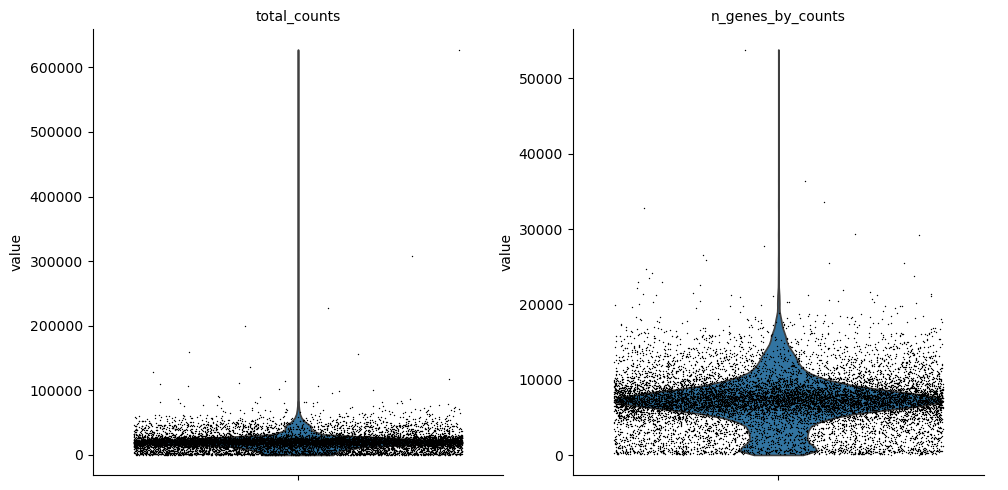

In [101]:
sc.pl.violin(atac, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)


In [ ]:
Filter peaks which expression is not detected:

In [102]:
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=10)
# but does in-place filtering and avoids copying the object

In [ ]:
Filter cells

In [103]:
mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 2000) & (x <= 15000))
# This is analogous to
#   sc.pp.filter_cells(atac, max_genes=15000)
#   sc.pp.filter_cells(atac, min_genes=2000)
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 4000) & (x <= 40000))

In [61]:
Let’s see how the data looks after filtering:

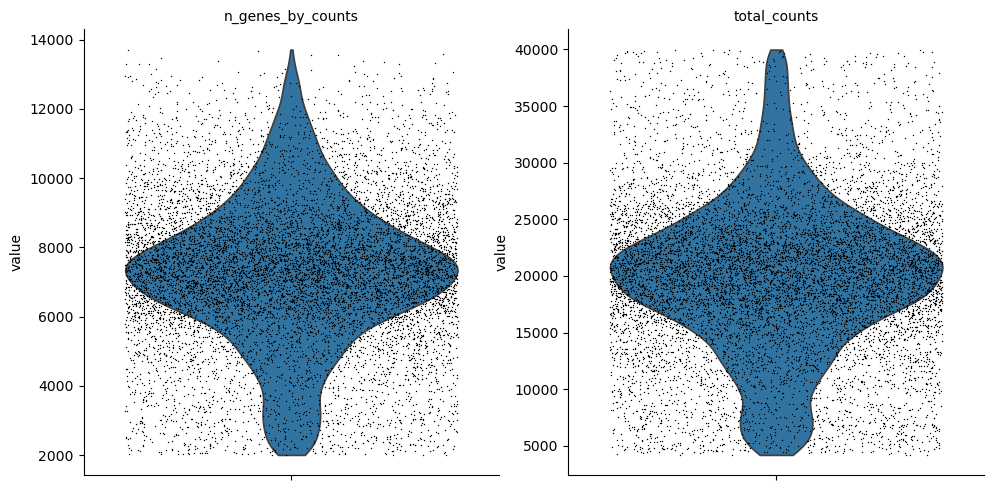

In [104]:
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

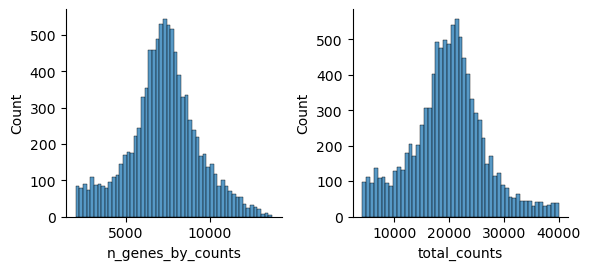

In [105]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])

In [ ]:
ATAC-specific QC

In [ ]:
Nucleosome signal
Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound
to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

In [106]:
atac.obs

,n_genes_by_counts,total_counts
AAACAGCCAATCCCTT-1,7253,20495.0
AAACAGCCAATGCGCT-1,6528,16674.0
AAACAGCCACCAACCG-1,3323,7658.0
AAACAGCCAGGATAAC-1,4267,10355.0
AAACAGCCAGTAGGTG-1,11633,39454.0
...,...,...
TTTGTTGGTGACATGC-1,5718,15272.0
TTTGTTGGTGTTAAAC-1,6629,17869.0
TTTGTTGGTTAGGATT-1,4267,10558.0
TTTGTTGGTTGGTTAG-1,6367,17054.0


In [107]:
atac.obs['NS']=1

In [110]:
atac.uns["files"] = {}
atac.uns["files"]["fragments"] = "/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz"

[W::hts_idx_load3] The index file is older than the data file: /Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz.tbi
Fetching Regions...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.57s/it]


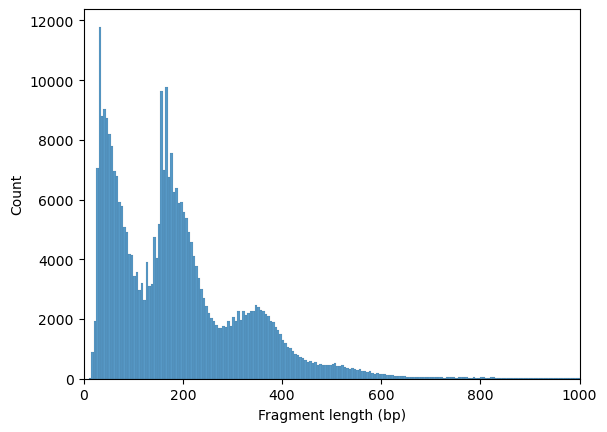

In [111]:
ac.pl.fragment_histogram(atac, region='chr1:1-2000000')

In [ ]:
The ratio of mono-nucleosome cut fragments to nucleosome-free fragments can be called nucleosome signal, and it can be estimated using a subset of fragments.

In [112]:
ac.tl.nucleosome_signal(atac, n=1e6)

[W::hts_idx_load3] The index file is older than the data file: /Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz.tbi
Reading Fragments: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:02<00:00, 393940.41it/s]


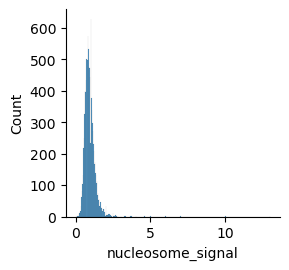

In [113]:
mu.pl.histogram(atac, "nucleosome_signal", kde=False)

In [ ]:
TSS enrichment
We can expect chromatin accessibility enriched around transcription start sites (TSS) compared to accessibility of flanking regions. Thus this measure averaged across multiple genes can serve as one more quality control metric.

The positions of transcription start sites can be obtained from the interval field of the gene annotation in the rna modality:

In [114]:
ac.tl.get_gene_annotation_from_rna(mdata['rna']).head(3)

,Chromosome,Start,End,gene_id,gene_name
MIR1302-2HG,chr1,29553,30267,ENSG00000243485,MIR1302-2HG
FAM138A,chr1,36080,36081,ENSG00000237613,FAM138A
OR4F5,chr1,65418,69055,ENSG00000186092,OR4F5


In [ ]:
TSS enrichment function will return an AnnData object with cells x bases dimensions where bases correspond to positions around TSS and are 
defined by extend_upstream and extend_downstream parameters, each of them being 1000 bp by default. It will also record tss_score in the 
original object.

In [115]:
tss = ac.tl.tss_enrichment(mdata, n_tss=1000)  # by default, features=ac.tl.get_gene_annotation_from_rna(mdata)

[W::hts_idx_load3] The index file is older than the data file: /Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz.tbi
Fetching Regions...: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 106.46it/s]
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


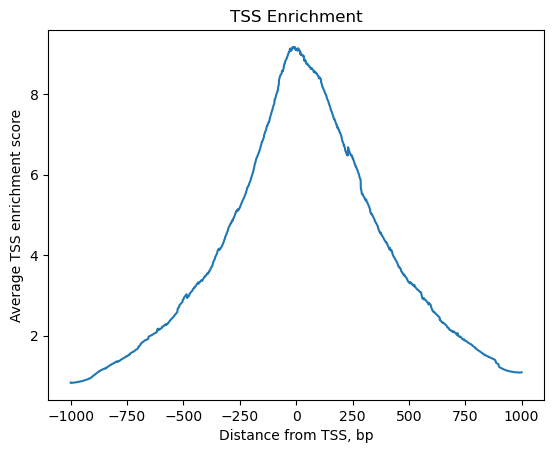

In [116]:
ac.pl.tss_enrichment(tss)

In [ ]:
Normalisation

In [117]:
# Save original counts
atac.layers["counts"] = atac.X

In [ ]:
There can be multiple options for ATAC-seq data normalisation.

One is latent semantic indexing that is frequently used for processing ATAC-seq datasets. First, it constructs term-document matrix from the original count matrix. Then the singular value decomposition (SVD) — the same technique that convential principal component analysis uses — is used to generate LSI components. Note that there are different flavours of computing TF-IDF, e.g. see this blog post about that.

TF-IDF normalisation is implemented in the muon’s ATAC module:

In [118]:
ac.pp.tfidf(atac, scale_factor=1e4)

In [ ]:
Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [119]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/var/folders/wt/z___z_1n7mb_ywtv9xc9qbgw0000gn/T/ipykernel_25023/27188036.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [ ]:
Feature selection
We will label highly variable peaks that we’ll use for downstream analysis.

In [120]:
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)

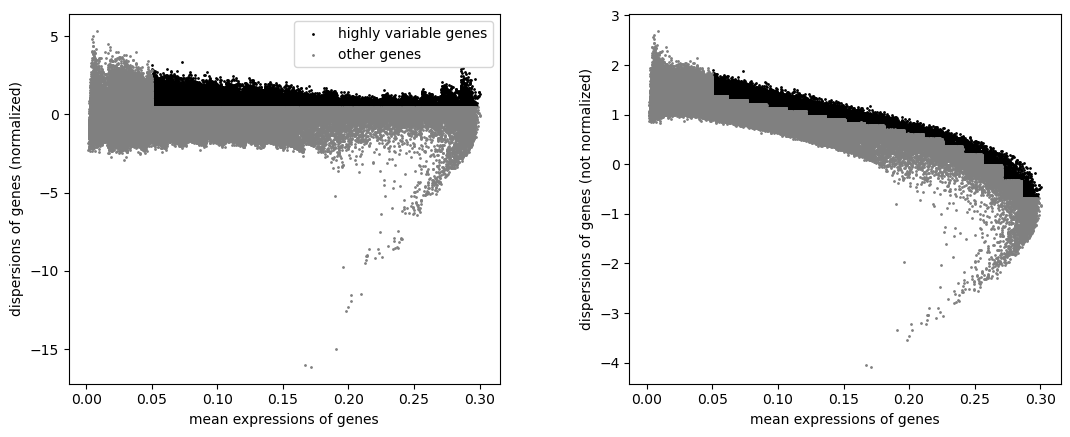

In [121]:
sc.pl.highly_variable_genes(atac)

In [122]:
np.sum(atac.var.highly_variable)

19430

In [ ]:
Scaling
For uniformity, and for consequent visualisation, we’ll save log-transformed counts in a .raw slot:

In [123]:
atac.raw = atac

In [ ]:
Analysis
After filtering out low-quality cells, normalising the counts matrix, and selecting highly varianbe peaks, we can already use this data for multimodal integration.

However, as in the case of gene expression, we will study this data individually first and will run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types. This might be useful later to compare cell type definition between modalities.

LSI
When working on TF-IDF counts, sc.tl.pca or ac.tl.lsi can be used to get latent components

In [124]:
ac.tl.lsi(atac)

In [ ]:
We find the first component is typically associated with number of peaks or counts per cell so it is reasonable to remove it

In [125]:
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:,1:]
atac.varm["LSI"] = atac.varm["LSI"][:,1:]
atac.uns["lsi"]["stdev"] = atac.uns["lsi"]["stdev"][1:]

In [ ]:
The respective neighbourhood graph can be generated with sc.tl.neighbors

In [126]:
sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=10, n_pcs=30)

In [ ]:
PCA
For this notebook, we are using PCA on the log-normalised counts in atac.X as described above.

In [127]:
sc.pp.scale(atac)
sc.tl.pca(atac)

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
We can only colour our plots by cut counts in individual peaks with scanpy

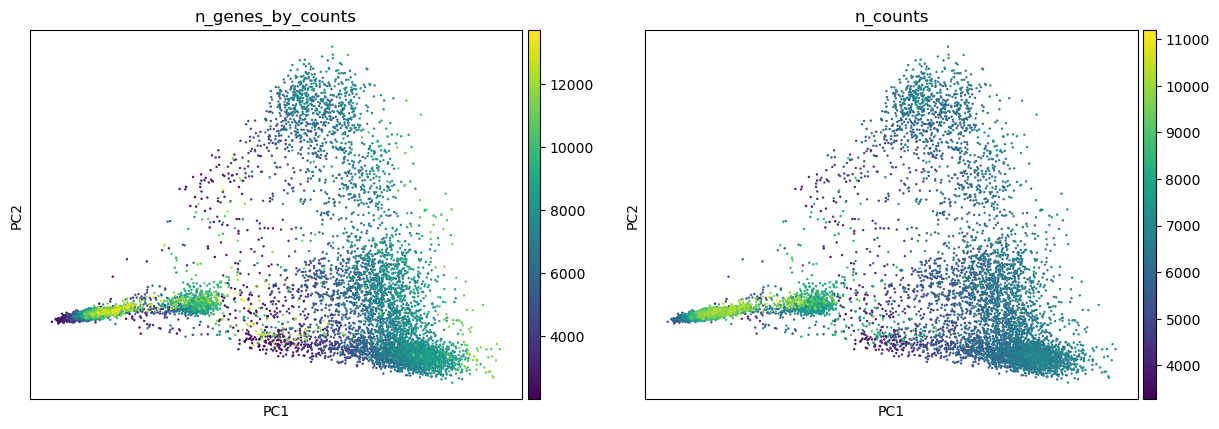

In [128]:
sc.pl.pca(atac, color=["n_genes_by_counts", "n_counts"])

In [ ]:
With muon’s ATAC module, we can plot average values for cut counts in peaks of different types (promoter/distal) that are assigned to 
respective genes — just by providing gene names.

For that to work, we need the peak annotation table with gene -> peak correspondence. The peak_annotation.tsv file was detected and loaded
automatically when we loaded the original data. Here is how the processed peak annotation table looks like:

In [130]:
atac.uns

OrderedDict([('files',
              {'fragments': '/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz'}),
             ('log1p', {'base': None}),
             ('hvg', {'flavor': 'seurat'}),
             ('lsi',
              {'stdev': array([10.8366585 ,  5.2230196 ,  5.0277977 ,  3.0723503 ,  2.424738  ,
                       2.1983302 ,  2.0070622 ,  1.8197713 ,  1.7905867 ,  1.6630728 ,
                       1.5450025 ,  1.4919825 ,  1.4047841 ,  1.367276  ,  1.3399178 ,
                       1.3207016 ,  1.2877754 ,  1.2254554 ,  1.2134699 ,  1.1663224 ,
                       1.1330765 ,  1.1087438 ,  1.1030229 ,  1.0541164 ,  1.0514216 ,
                       1.0402933 ,  1.0256107 ,  1.022395  ,  1.0107952 ,  1.0082409 ,
                       0.994525  ,  0.99023455,  0.9864325 ,  0.9811133 ,  0.97685474,
                       0.9725921 ,  0.9661363 ,  0.96424514,

In [131]:
print(atac.uns.keys())

odict_keys(['files', 'log1p', 'hvg', 'lsi', 'neighbors', 'pca'])


In [132]:
atac.var.head()

,gene_ids,feature_types,genome,interval,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
chr1:10109-10357,chr1:10109-10357,Peaks,GRCh38,chr1:10109-10357,85,0.010916,99.286254,130.0,False,0.026752,1.774558,2.197926,0.010196,0.128935
chr1:180730-181630,chr1:180730-181630,Peaks,GRCh38,chr1:180730-181630,187,0.028886,98.429759,344.0,False,0.048830,1.391417,0.585073,0.021002,0.176441
chr1:191491-191736,chr1:191491-191736,Peaks,GRCh38,chr1:191491-191736,61,0.006886,99.487782,82.0,False,0.016919,1.575534,1.060551,0.006738,0.102870
chr1:267816-268196,chr1:267816-268196,Peaks,GRCh38,chr1:267816-268196,122,0.019901,98.975565,237.0,False,0.030394,1.336870,-0.303365,0.013057,0.139614
chr1:586028-586373,chr1:586028-586373,Peaks,GRCh38,chr1:586028-586373,81,0.013603,99.319842,162.0,False,0.026925,1.621163,1.321310,0.010194,0.130808


In [134]:
ac.tl.add_peak_annotation(atac, annotation="/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/PBMC_healthy_donor_granulocyte_10K/atac/pbmc_granulocyte_sorted_10k_atac_peak_annotation.tsv")

In [135]:
atac.uns['atac']['peak_annotation'].tail()

,peak,distance,peak_type
gene,,,
AC213203.2,KI270713.1:20444-22615,9913,distal
AC213203.2,KI270713.1:27118-28927,3601,distal
AC213203.2,KI270713.1:29485-30706,1822,distal
AC213203.2,KI270713.1:31511-32072,456,distal
AC213203.1,KI270713.1:37129-37638,1723,distal


In [ ]:
Now we can plot average cut values in peaks corresponding to genes just by providing a gene name. By default, values in atac.raw are used for plotting.

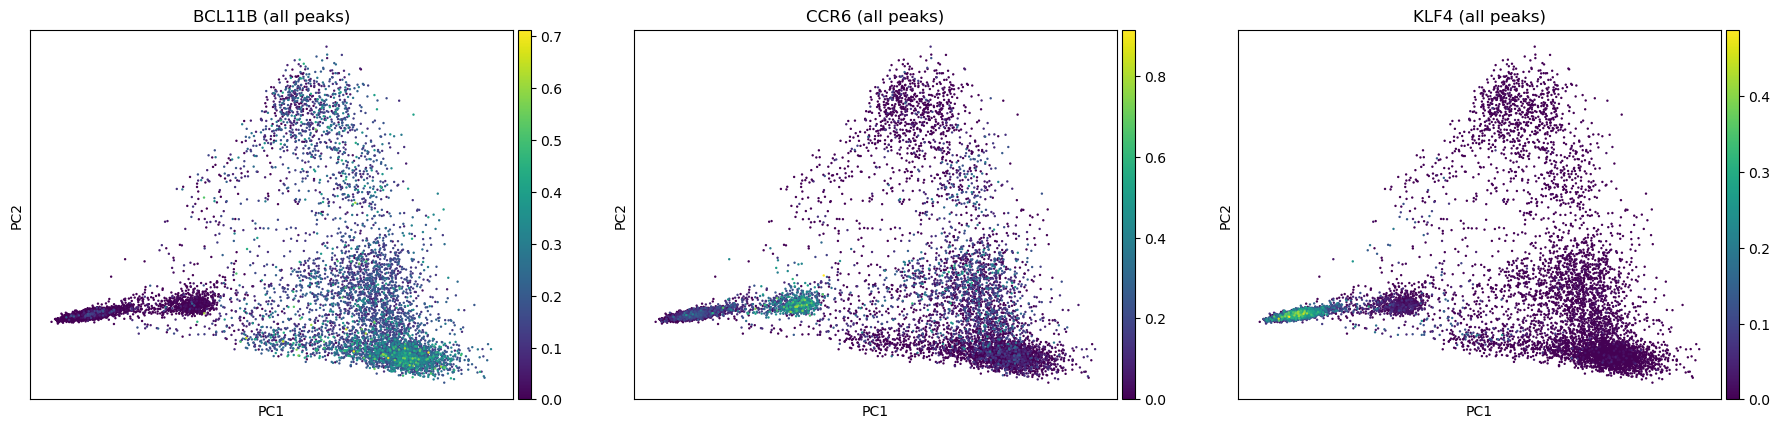

In [136]:
ac.pl.pca(atac, color=["BCL11B", "CCR6", "KLF4"], average="total")

In [ ]:
We can also average peaks of each type separately

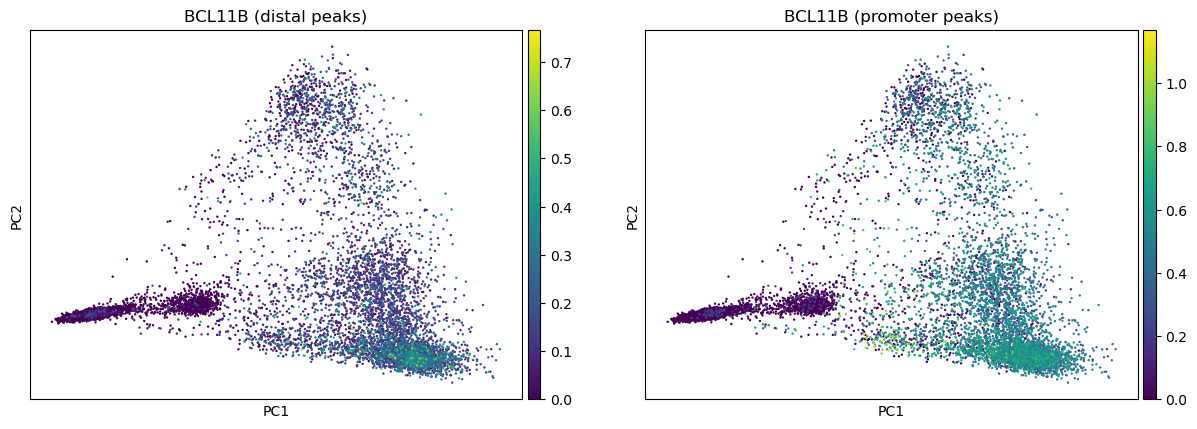

In [137]:
ac.pl.pca(atac, color="BCL11B", average="peak_type")

In [ ]:
We see how this component space here resembles the one based on gene expression from the previous notebook. Looking at top loadings of first two components, we see how peaks linked to BCL11B (ENSG00000127152) and KLF4 (ENSG00000136826) demarcate lympohoid / myeloid axis while peaks linked to CCR6 (ENSG00000112486) define B cell axis.

Now we will compute a neighbourhood graph for cells that we’ll use for clustering later on.

In [138]:
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=30)

In [ ]:
Non-linear dimensionality reduction and clustering
To stay comparable to the gene expression notebook, we will use leiden to cluster cells.

In [139]:
sc.tl.leiden(atac, resolution=.5)

In [ ]:
We’ll use UMAP latent space for visualisation below.

In [140]:
sc.tl.umap(atac, spread=1.5, min_dist=.5, random_state=20)

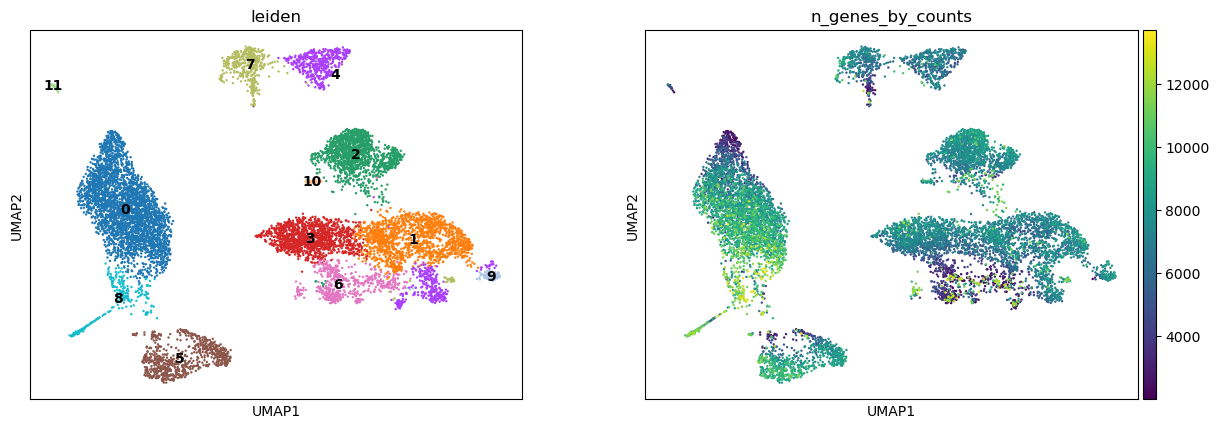

In [141]:
sc.pl.umap(atac, color=["leiden", "n_genes_by_counts"], legend_loc="on data")

In [ ]:
Again, we can use the functionality of the ATAC module in muon to color plots by cut values in peaks correspoonding to a certain gene:

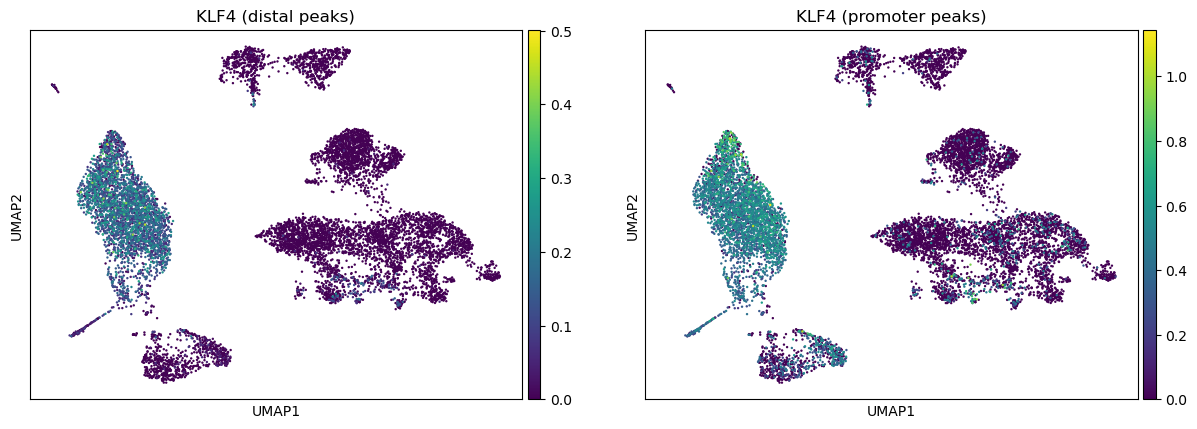

In [142]:
ac.pl.umap(atac, color=["KLF4"], average="peak_type")

In [ ]:
Marker genes and celltypes
We will now define cell types based on chromatin accessibility.



In [143]:
ac.tl.rank_peaks_groups(atac, 'leiden', method='t-test')

In [147]:
result = atac.uns['rank_genes_groups']
groups = result['names'].dtype.names

pd.set_option("display.max_columns", 50)

df = pd.DataFrame({
  f"{group}_{key}": result[key][group]
    for group in groups
    for key in ['names', 'logfoldchanges', 'pvals_adj']
})

df.head(10)

,0_names,0_logfoldchanges,0_pvals_adj,1_names,1_logfoldchanges,1_pvals_adj,2_names,2_logfoldchanges,2_pvals_adj,3_names,3_logfoldchanges,3_pvals_adj,4_names,4_logfoldchanges,4_pvals_adj,5_names,5_logfoldchanges,5_pvals_adj,6_names,6_logfoldchanges,6_pvals_adj,7_names,7_logfoldchanges,7_pvals_adj,8_names,8_logfoldchanges,8_pvals_adj,9_names,9_logfoldchanges,9_pvals_adj,10_names,10_logfoldchanges,10_pvals_adj,11_names,11_logfoldchanges,11_pvals_adj
0,chr9:107480158-107492721,3.117956,0.0,chr14:22536559-22563070,0.959907,2.253257e-277,chr2:86783559-86792275,2.729052,0.000000e+00,chr14:99255246-99275454,1.300611,1.416658e-277,chr1:24909406-24919504,2.327296,1.996309e-156,chr22:41917087-41929835,2.300269,2.197595e-260,chr19:1230013-1281741,0.365701,1.300956e-29,chr17:83076201-83103570,1.627484,4.009087e-146,chr19:4429555-4432878,2.329716,3.230081e-36,chr16:81519063-81525049,2.554753,7.993087e-22,chr16:88448143-88480965,1.103022,4.505805e-10,chr10:133265906-133281093,2.136569,1.618011e-09
1,chr20:50269694-50277398,4.403715,0.0,chr10:8041366-8062418,1.085382,8.322303e-180,chr11:66311352-66319301,1.022712,9.218482e-287,chr14:99223600-99254668,1.295874,3.179038e-200,chr2:144507361-144525092,1.793423,4.116284e-141,chr22:41931503-41942227,1.835732,1.732349e-232,chr19:12774552-12797715,0.396359,9.912916e-24,chr1:24909406-24919504,2.316658,1.367351e-102,chr9:107480158-107492721,1.062518,3.003991e-33,chr15:39623205-39625650,3.176436,6.327288e-21,chr14:101807949-101830976,0.671763,2.436318e-07,chr19:1230013-1281741,0.532566,2.733682e-09
2,chr22:38950570-38958424,3.876105,0.0,chr14:99255246-99275454,1.033986,3.571957e-174,chr14:99255246-99275454,1.260702,3.984570e-291,chr14:22536559-22563070,0.837910,8.272288e-185,chr4:6198055-6202103,3.534745,1.060436e-130,chr2:231669797-231676530,3.540435,3.428620e-210,chr14:99255246-99275454,0.834771,2.499077e-21,chr2:28388837-28416648,0.786072,2.695975e-101,chr6:11730442-11733107,2.143514,2.803411e-32,chr17:40536232-40543738,2.130046,9.186225e-21,chr19:16363226-16378669,0.688254,3.851677e-07,chr2:231704562-231718074,0.969713,2.871398e-08
3,chr1:182143071-182150314,3.769403,0.0,chr7:142782798-142813716,0.858586,1.410299e-162,chr12:10552886-10555668,4.024043,1.904177e-227,chr14:99181080-99219442,1.467195,1.569918e-171,chr2:241762278-241764383,3.488036,3.290276e-125,chr19:5125450-5140568,2.253221,6.493188e-207,chr19:1061757-1096608,0.459164,3.105206e-20,chr1:184386243-184389335,3.485958,5.277613e-89,chr10:70493034-70495432,3.519541,4.571558e-32,chr22:44709028-44711972,3.296615,1.092623e-20,chr4:185202045-185205006,1.650006,6.479668e-07,chr6:32966117-32979035,1.040306,4.444361e-08
4,chr5:1476663-1483241,3.729587,0.0,chr14:91240967-91256390,1.051127,1.854036e-150,chr2:136122469-136138482,0.929373,3.162865e-250,chr7:142782798-142813716,0.910924,2.138304e-174,chr20:24948563-24956577,2.414458,7.051033e-125,chr6:167111604-167115345,4.098644,2.650937e-179,chr5:177423914-177460579,0.397025,1.580926e-18,chr20:24948563-24956577,2.452104,7.906093e-86,chr6:56953558-56956183,2.995292,4.300562e-30,chr11:114072228-114076352,3.642495,1.346240e-20,chr1:2493438-2508142,2.130142,7.299882e-07,chr19:21593423-21595308,4.369821,1.544645e-07
5,chr9:134369462-134387253,2.168655,0.0,chr14:99223600-99254668,1.081210,6.579977e-144,chr14:99181080-99219442,1.579889,3.995408e-239,chr19:16363226-16378669,0.911323,3.289607e-164,chr2:86783559-86792275,2.295431,1.578539e-118,chr6:150598919-150601318,3.697389,1.319800e-179,chr19:14505027-14524641,0.545965,2.483256e-17,chr22:37161134-37168690,2.241693,1.735597e-82,chr7:98641522-98642532,7.707992,5.834025e-30,chr11:114065160-114066911,4.931528,4.847988e-20,chr5:35850992-35860227,1.378513,7.111439e-07,chr17:40306445-40353516,0.850153,2.501329e-07
6,chr3:72092464-72103763,2.446953,0.0,chr20:59157931-59168100,1.171861,3.078927e-138,chr1:24500773-24509089,1.320954,5.443865e-216,chr17:40601555-40611036,1.577217,1.547174e-153,chr4:1199596-1209141,1.638857,6.097962e-116,chr19:50414004-50420358,2.934500

In [ ]:
Having studied markers of individual clusters, we will filter some cells out before assigning cell types names to clusters: likely doublets in clusters 10 and 14, proliferating cells in 15, stressed cells in 16.

In [148]:
#mu.pp.filter_obs(atac, "leiden", lambda x: ~x.isin(["10", "14", "15", "16"]))
# Analogous to
#   atac = atac[~atac.obs.leiden.isin(["10", "14", "15", "16"])]
# but doesn't copy the object

In [169]:
new_cluster_names = {
    "1": "CD4+ memory T", "2": "CD8+ naive T", "3": "CD4+ naive T",
    "5": "Naive B", "8": "Intermediate or CD16 mono", 
    "9": "MAIT", "6": "Mixed T cell",
    "0": "CD14 mono", "4": "CD8+ activated T", "7": "NK",
    "11": "Mixed", 
}

In [170]:
atac.obs['celltype'] = atac.obs.leiden.astype("str").values
atac.obs.celltype = atac.obs.celltype.astype("category").cat.rename_categories(new_cluster_names)

In [172]:
atac.obs.celltype

AAACAGCCAATCCCTT-1       CD4+ memory T
AAACAGCCAATGCGCT-1        CD4+ naive T
AAACAGCCACCAACCG-1        Mixed T cell
AAACAGCCAGGATAAC-1        CD4+ naive T
AAACAGCCAGTAGGTG-1        CD8+ naive T
                            ...       
TTTGTTGGTGACATGC-1        CD8+ naive T
TTTGTTGGTGTTAAAC-1        CD8+ naive T
TTTGTTGGTTAGGATT-1                  NK
TTTGTTGGTTGGTTAG-1       CD4+ memory T
TTTGTTGGTTTGCAGA-1    CD8+ activated T
Name: celltype, Length: 10042, dtype: category
Categories (11, object): ['CD14 mono', 'CD4+ memory T', 'Mixed', 'CD8+ naive T', ..., 'Mixed T cell', 'NK', 'Intermediate or CD16 mono', 'MAIT']

In [173]:
atac.obs['celltype'].value_counts()

celltype
CD14 mono                    3065
CD4+ memory T                1458
CD8+ naive T                 1323
CD4+ naive T                 1258
CD8+ activated T              783
Naive B                       743
Mixed T cell                  551
NK                            469
Intermediate or CD16 mono     274
MAIT                           95
Mixed                          23
Name: count, dtype: int64

In [ ]:
We will also re-order categories for the next plots:

In [175]:
atac.obs.celltype.cat.reorder_categories([
    "CD4+ naive T", "CD4+ memory T", "MAIT",
    "CD8+ naive T", "NK",
    "CD14 mono", "Intermediate or CD16 mono", "Naive B",
    "Mixed T cell", "CD8+ activated T", "Mixed"], ordered=True)

AAACAGCCAATCCCTT-1       CD4+ memory T
AAACAGCCAATGCGCT-1        CD4+ naive T
AAACAGCCACCAACCG-1        Mixed T cell
AAACAGCCAGGATAAC-1        CD4+ naive T
AAACAGCCAGTAGGTG-1        CD8+ naive T
                            ...       
TTTGTTGGTGACATGC-1        CD8+ naive T
TTTGTTGGTGTTAAAC-1        CD8+ naive T
TTTGTTGGTTAGGATT-1                  NK
TTTGTTGGTTGGTTAG-1       CD4+ memory T
TTTGTTGGTTTGCAGA-1    CD8+ activated T
Name: celltype, Length: 10042, dtype: category
Categories (11, object): ['CD4+ naive T' < 'CD4+ memory T' < 'MAIT' < 'CD8+ naive T' ... 'Naive B' < 'Mixed T cell' < 'CD8+ activated T' < 'Mixed']

In [164]:
? atac.obs.celltype.cat.reorder_categories

Signature:  atac.obs.celltype.cat.reorder_categories(*args, **kwargs)
Docstring:
Reorder categories as specified in new_categories.

``new_categories`` need to include all old categories and no new category
items.

Parameters
----------
new_categories : Index-like
   The categories in new order.
ordered : bool, optional
   Whether or not the categorical is treated as a ordered categorical.
   If not given, do not change the ordered information.

Returns
-------
Categorical
    Categorical with reordered categories.

Raises
------
ValueError
    If the new categories do not contain all old category items or any
    new ones

See Also
--------
rename_categories : Rename categories.
add_categories : Add new categories.
remove_categories : Remove the specified categories.
remove_unused_categories : Remove categories which are not used.
set_categories : Set the categories to the specified ones.

Examples
--------
For :class:`pandas.Series`:

>>> ser = pd.Series(['a', 'b', 'c', 'a'], dtype='

In [176]:
import matplotlib
import matplotlib.pyplot as plt

cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(atac.obs.celltype.cat.categories)))

atac.uns["celltype_colors"] = list(map(matplotlib.colors.to_hex, colors))

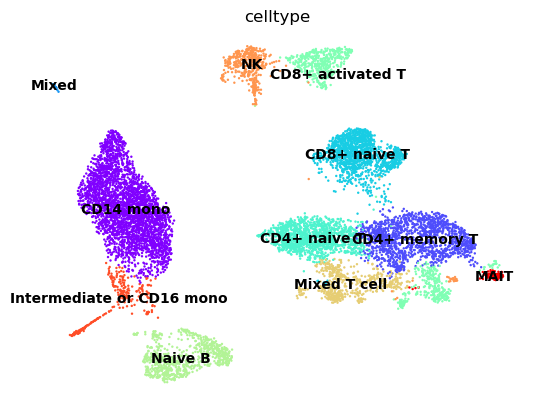

In [177]:
sc.pl.umap(atac, color="celltype", legend_loc="on data", frameon=False)

In [ ]:
Finally, we’ll visualise some marker genes across cell types.

In [178]:
marker_genes = ['IL7R', 'TRAC',
                'GATA3',
                'SLC4A10',
                'CD8A', 'CD8B', 'CD248', 'CCL5',
                'GNLY', 'NKG7',
                'CD79A', 'MS4A1', 'IGHD', 'IGHM', 'TNFRSF13C',
                'IL4R', 'KLF4', 'LYZ', 'S100A8', 'ITGAM', 'CD14',
                'FCGR3A', 'MS4A7', 'CST3',
                'CLEC10A', 'IRF8', 'TCF4']

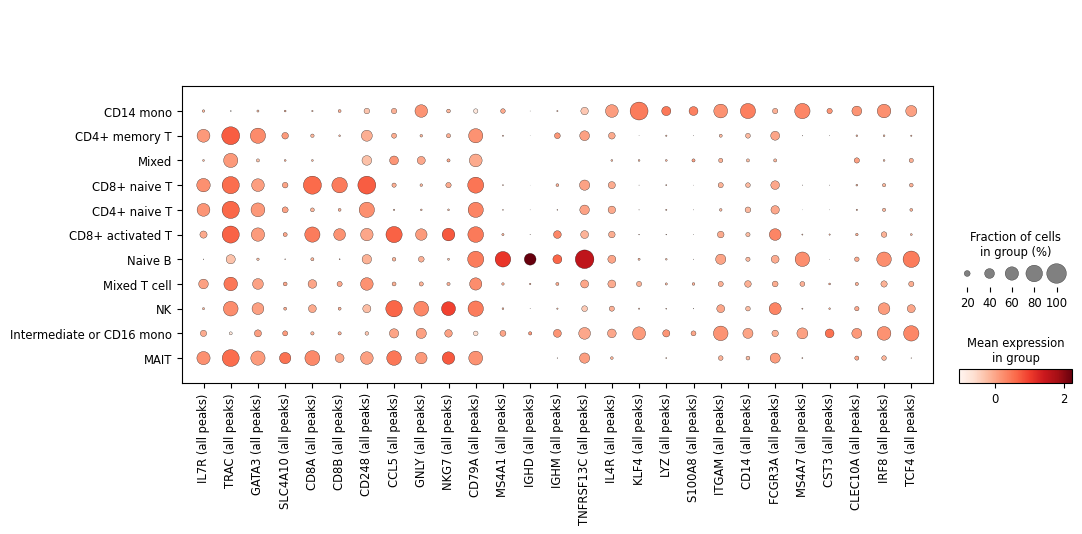

In [179]:
ac.pl.dotplot(atac, marker_genes, groupby='celltype')

In [183]:
mdata = mu.MuData({"atac": atac})
mu.write("/Users/siddharthadas/Desktop/DEEP_LEARNING_WITH_SINGLE_CELL_MULTIOMICS/pbmc_integration/atac.h5mu", mdata)

/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/Users/siddharthadas/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/mudat

In [184]:
atac

AnnData object with n_obs × n_vars = 10042 × 106086
    obs: 'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'files', 'log1p', 'hvg', 'lsi', 'neighbors', 'pca', 'atac', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups', 'celltype_colors'
    obsm: 'X_lsi', 'X_pca', 'X_umap'
    varm: 'LSI', 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'